Starting Collaborative Filtering Evaluation...
Training data shape: (5995, 4)
Testing data shape: (915, 4)
User-Item matrix shape: (183, 1574)

Evaluating user_based with cosine similarity...

USER_BASED_COSINE Results:
MSE: 1.6012
RMSE: 1.2654
MAE: 0.9631
NMAE: 0.2408

Evaluating user_based with pearson similarity...

USER_BASED_PEARSON Results:
MSE: 5.6032
RMSE: 2.3671
MAE: 1.9008
NMAE: 0.4752

Evaluating item_based with cosine similarity...

ITEM_BASED_COSINE Results:
MSE: 1.6586
RMSE: 1.2879
MAE: 1.0023
NMAE: 0.2506

Evaluating item_based with pearson similarity...

ITEM_BASED_PEARSON Results:
MSE: 5.1164
RMSE: 2.2620
MAE: 1.7828
NMAE: 0.4457

Creating Visualizations...


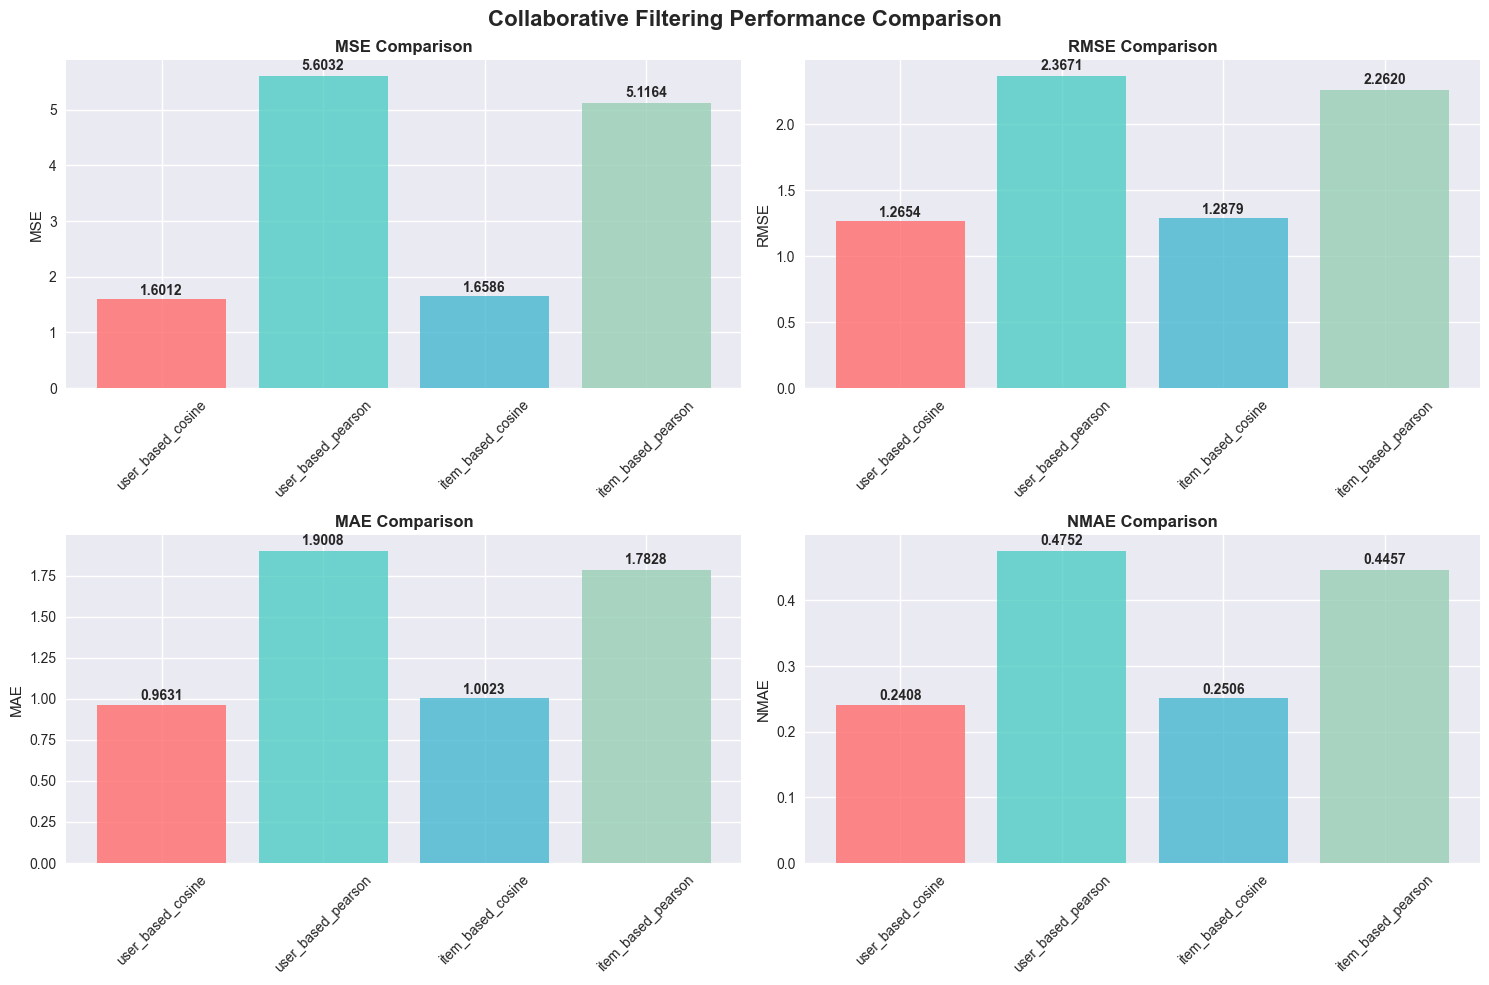

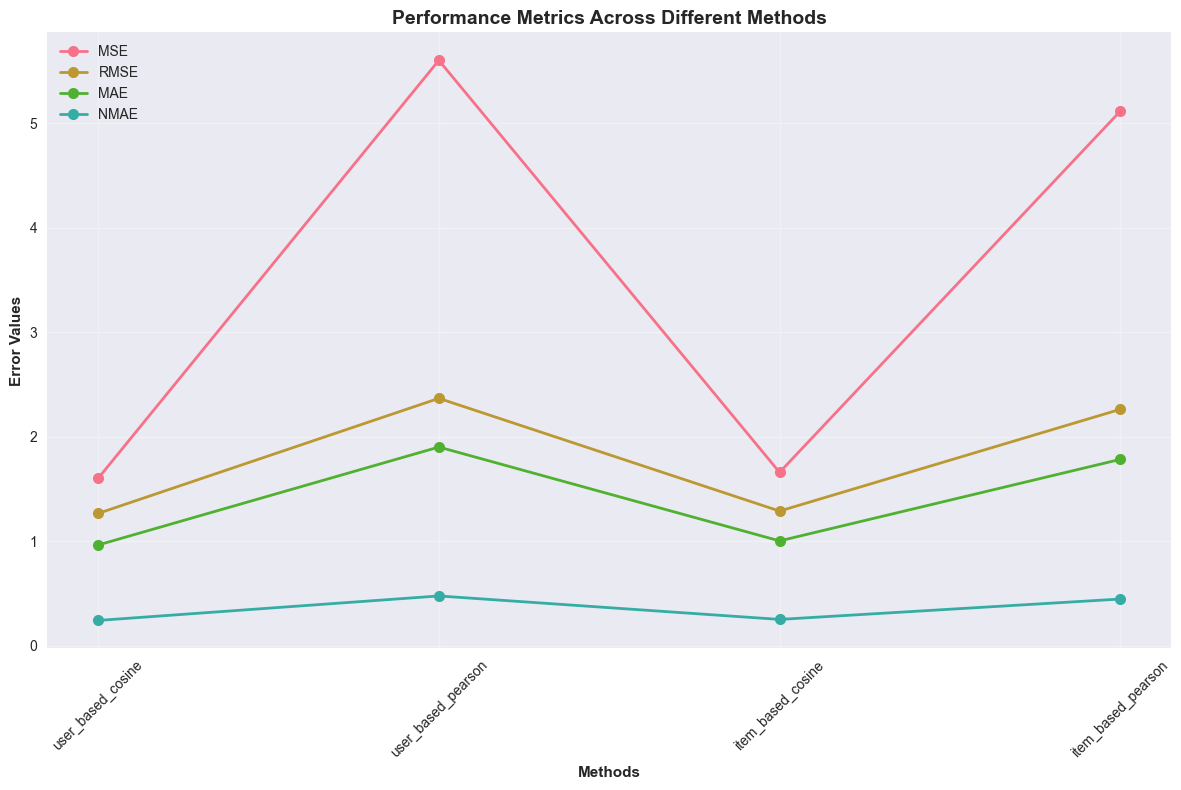


PERFORMANCE SUMMARY TABLE
      user_based_cosine  user_based_pearson  item_based_cosine  \
MSE              1.6012              5.6032             1.6586   
RMSE             1.2654              2.3671             1.2879   
MAE              0.9631              1.9008             1.0023   
NMAE             0.2408              0.4752             0.2506   

      item_based_pearson  
MSE               5.1164  
RMSE              2.2620  
MAE               1.7828  
NMAE              0.4457  

BEST PERFORMING METHODS
MSE: user_based_cosine (1.6012)
RMSE: user_based_cosine (1.2654)
MAE: user_based_cosine (0.9631)
NMAE: user_based_cosine (0.2408)

Evaluation Complete!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')
import os
print(os.path.exists('../data/collabrative/user_based_training_set.csv'))
class CollaborativeFiltering:
    def __init__(self):
        self.user_item_matrix = None
        self.user_similarity = None
        self.item_similarity = None
        self.user_mean_ratings = None
        self.item_mean_ratings = None
        
    def load_data(self, train_path, test_path):
        """Load training and testing data"""
        self.train_df = pd.read_csv(train_path)
        self.test_df = pd.read_csv(test_path)
        
        # Create user-item matrix
        self.user_item_matrix = self.train_df.pivot_table(
            index='username', 
            columns='id_product', 
            values='rating'
        ).fillna(0)
        
        # Calculate mean ratings
        self.user_mean_ratings = self.train_df.groupby('username')['rating'].mean()
        self.item_mean_ratings = self.train_df.groupby('id_product')['rating'].mean()
        
        print(f"Training data shape: {self.train_df.shape}")
        print(f"Testing data shape: {self.test_df.shape}")
        print(f"User-Item matrix shape: {self.user_item_matrix.shape}")
        
    def calculate_user_similarity(self, method='cosine'):
        """Calculate user-user similarity"""
        if method == 'cosine':
            # Replace 0 with NaN for better cosine similarity calculation
            matrix = self.user_item_matrix.replace(0, np.nan)
            matrix_filled = matrix.fillna(0)
            self.user_similarity = cosine_similarity(matrix_filled)
        elif method == 'pearson':
            n_users = len(self.user_item_matrix)
            self.user_similarity = np.zeros((n_users, n_users))
            
            for i in range(n_users):
                for j in range(n_users):
                    if i == j:
                        self.user_similarity[i, j] = 1.0
                    else:
                        user_i = self.user_item_matrix.iloc[i].values
                        user_j = self.user_item_matrix.iloc[j].values
                        
                        # Find common items (non-zero ratings)
                        mask = (user_i != 0) & (user_j != 0)
                        if np.sum(mask) > 1:
                            corr, _ = pearsonr(user_i[mask], user_j[mask])
                            self.user_similarity[i, j] = corr if not np.isnan(corr) else 0
                        else:
                            self.user_similarity[i, j] = 0
                            
    def calculate_item_similarity(self, method='cosine'):
        """Calculate item-item similarity"""
        if method == 'cosine':
            matrix = self.user_item_matrix.T.replace(0, np.nan)
            matrix_filled = matrix.fillna(0)
            self.item_similarity = cosine_similarity(matrix_filled)
        elif method == 'pearson':
            n_items = len(self.user_item_matrix.columns)
            self.item_similarity = np.zeros((n_items, n_items))
            
            for i in range(n_items):
                for j in range(n_items):
                    if i == j:
                        self.item_similarity[i, j] = 1.0
                    else:
                        item_i = self.user_item_matrix.iloc[:, i].values
                        item_j = self.user_item_matrix.iloc[:, j].values
                        
                        # Find common users (non-zero ratings)
                        mask = (item_i != 0) & (item_j != 0)
                        if np.sum(mask) > 1:
                            corr, _ = pearsonr(item_i[mask], item_j[mask])
                            self.item_similarity[i, j] = corr if not np.isnan(corr) else 0
                        else:
                            self.item_similarity[i, j] = 0
    
    def predict_user_based(self, user, item, k=50):
        """User-based collaborative filtering prediction"""
        if user not in self.user_item_matrix.index:
            return self.item_mean_ratings.get(item, 3.0)
        
        if item not in self.user_item_matrix.columns:
            return self.user_mean_ratings.get(user, 3.0)
            
        user_idx = self.user_item_matrix.index.get_loc(user)
        item_idx = self.user_item_matrix.columns.get_loc(item)
        
        # Get similarities for this user
        similarities = self.user_similarity[user_idx]
        
        # Find users who rated this item
        rated_users = self.user_item_matrix.iloc[:, item_idx] != 0
        rated_users_indices = np.where(rated_users)[0]
        
        if len(rated_users_indices) == 0:
            return self.user_mean_ratings.get(user, 3.0)
        
        # Get similarities and ratings for users who rated this item
        valid_similarities = similarities[rated_users_indices]
        valid_ratings = self.user_item_matrix.iloc[rated_users_indices, item_idx].values
        
        if len(valid_similarities) == 0:
            return self.user_mean_ratings.get(user, 3.0)
        
        # Sort by similarity and take top-k
        top_k_indices = np.argsort(valid_similarities)[-k:]
        top_similarities = valid_similarities[top_k_indices]
        top_ratings = valid_ratings[top_k_indices]
        
        # Calculate weighted average
        if np.sum(np.abs(top_similarities)) == 0:
            return self.user_mean_ratings.get(user, 3.0)
        
        prediction = np.sum(top_similarities * top_ratings) / np.sum(np.abs(top_similarities))
        return max(1, min(5, prediction))
    
    def predict_item_based(self, user, item, k=50):
        """Item-based collaborative filtering prediction"""
        if user not in self.user_item_matrix.index:
            return self.item_mean_ratings.get(item, 3.0)
        
        if item not in self.user_item_matrix.columns:
            return self.user_mean_ratings.get(user, 3.0)
            
        user_idx = self.user_item_matrix.index.get_loc(user)
        item_idx = self.user_item_matrix.columns.get_loc(item)
        
        # Get similarities for this item
        similarities = self.item_similarity[item_idx]
        
        # Find items rated by this user
        rated_items = self.user_item_matrix.iloc[user_idx] != 0
        rated_items_indices = np.where(rated_items)[0]
        
        if len(rated_items_indices) == 0:
            return self.item_mean_ratings.get(item, 3.0)
        
        # Get similarities and ratings for items rated by this user
        valid_similarities = similarities[rated_items_indices]
        valid_ratings = self.user_item_matrix.iloc[user_idx, rated_items_indices].values
        
        if len(valid_similarities) == 0:
            return self.item_mean_ratings.get(item, 3.0)
        
        # Sort by similarity and take top-k
        top_k_indices = np.argsort(valid_similarities)[-k:]
        top_similarities = valid_similarities[top_k_indices]
        top_ratings = valid_ratings[top_k_indices]
        
        # Calculate weighted average
        if np.sum(np.abs(top_similarities)) == 0:
            return self.item_mean_ratings.get(item, 3.0)
        
        prediction = np.sum(top_similarities * top_ratings) / np.sum(np.abs(top_similarities))
        return max(1, min(5, prediction))
    
    def evaluate(self, method='user_based', similarity='cosine'):
        """Evaluate the recommendation system"""
        print(f"\nEvaluating {method} with {similarity} similarity...")
        
        # Calculate similarity matrix
        if method == 'user_based':
            self.calculate_user_similarity(similarity)
        else:
            self.calculate_item_similarity(similarity)
        
        predictions = []
        actuals = []
        
        # Make predictions for test set
        for _, row in self.test_df.iterrows():
            user = row['username']
            item = row['id_product']
            actual = row['rating']
            
            if method == 'user_based':
                pred = self.predict_user_based(user, item)
            else:
                pred = self.predict_item_based(user, item)
            
            predictions.append(pred)
            actuals.append(actual)
        
        predictions = np.array(predictions)
        actuals = np.array(actuals)
        
        # Calculate metrics
        mse = mean_squared_error(actuals, predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(actuals, predictions)
        
        # NMAE (Normalized MAE) - normalized by rating range
        rating_range = 5 - 1  # assuming 1-5 rating scale
        nmae = mae / rating_range
        
        return {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'NMAE': nmae,
            'predictions': predictions,
            'actuals': actuals
        }

def run_evaluation():
    """Run complete evaluation for all methods"""
    
    # Initialize the system
    cf = CollaborativeFiltering()
    
    # Load data
    train_path = '../data/collabrative/user_based_training_set.csv'
    test_path = '../data/collabrative/user_based_testing_set.csv'
    
    cf.load_data(train_path, test_path)
    
    # Define methods to evaluate
    methods = [
        ('user_based', 'cosine'),
        ('user_based', 'pearson'),
        ('item_based', 'cosine'),
        ('item_based', 'pearson')
    ]
    
    results = {}
    
    # Evaluate each method
    for method, similarity in methods:
        method_name = f"{method}_{similarity}"
        results[method_name] = cf.evaluate(method, similarity)
        
        print(f"\n{method_name.upper()} Results:")
        print(f"MSE: {results[method_name]['MSE']:.4f}")
        print(f"RMSE: {results[method_name]['RMSE']:.4f}")
        print(f"MAE: {results[method_name]['MAE']:.4f}")
        print(f"NMAE: {results[method_name]['NMAE']:.4f}")
    
    return results

def plot_results(results):
    """Create visualization of results"""
    
    # Prepare data for plotting
    methods = list(results.keys())
    metrics = ['MSE', 'RMSE', 'MAE', 'NMAE']
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Collaborative Filtering Performance Comparison', fontsize=16, fontweight='bold')
    
    # Plot each metric
    for i, metric in enumerate(metrics):
        ax = axes[i // 2, i % 2]
        
        values = [results[method][metric] for method in methods]
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
        
        bars = ax.bar(methods, values, color=colors, alpha=0.8)
        ax.set_title(f'{metric} Comparison', fontweight='bold')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Create line plot showing trends
    plt.figure(figsize=(12, 8))
    
    x_pos = range(len(methods))
    
    for metric in metrics:
        values = [results[method][metric] for method in methods]
        plt.plot(x_pos, values, marker='o', linewidth=2, markersize=8, label=metric)
    
    plt.xlabel('Methods', fontweight='bold')
    plt.ylabel('Error Values', fontweight='bold')
    plt.title('Performance Metrics Across Different Methods', fontsize=14, fontweight='bold')
    plt.xticks(x_pos, methods, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Create summary table
    print("\n" + "="*80)
    print("PERFORMANCE SUMMARY TABLE")
    print("="*80)
    
    df_results = pd.DataFrame({
        method: [results[method][metric] for metric in metrics]
        for method in methods
    }, index=metrics)
    
    print(df_results.round(4))
    
    # Find best performing method for each metric
    print("\n" + "="*80)
    print("BEST PERFORMING METHODS")
    print("="*80)
    
    for metric in metrics:
        best_method = min(methods, key=lambda x: results[x][metric])
        best_value = results[best_method][metric]
        print(f"{metric}: {best_method} ({best_value:.4f})")

if __name__ == "__main__":
    # Run the evaluation
    print("Starting Collaborative Filtering Evaluation...")
    print("="*60)
    
    results = run_evaluation()
    
    print("\n" + "="*60)
    print("Creating Visualizations...")
    
    plot_results(results)
    
    print("\nEvaluation Complete!")

Starting Collaborative Filtering Evaluation...

Loading data for user_based_cosine:
Training: ../data/collabrative/user_based_training_set.csv
Testing: ../data/collabrative/user_based_testing_set.csv

Evaluating user_based with cosine similarity...
Training data shape: (5995, 4)
Testing data shape: (915, 4)
User-Item matrix shape: (183, 1574)

USER_BASED_COSINE Results:
MSE: 1.6012
RMSE: 1.2654
MAE: 0.9631
NMAE: 0.2408

Loading data for user_based_pearson:
Training: ../data/collabrative/user_based_training_set.csv
Testing: ../data/collabrative/user_based_testing_set.csv

Evaluating user_based with pearson similarity...
Training data shape: (5995, 4)
Testing data shape: (915, 4)
User-Item matrix shape: (183, 1574)

USER_BASED_PEARSON Results:
MSE: 5.6032
RMSE: 2.3671
MAE: 1.9008
NMAE: 0.4752

Loading data for item_based_cosine:
Training: ../data/collabrative/item_based_training_set.csv
Testing: ../data/collabrative/item_based_testing_set.csv

Evaluating item_based with cosine similarity

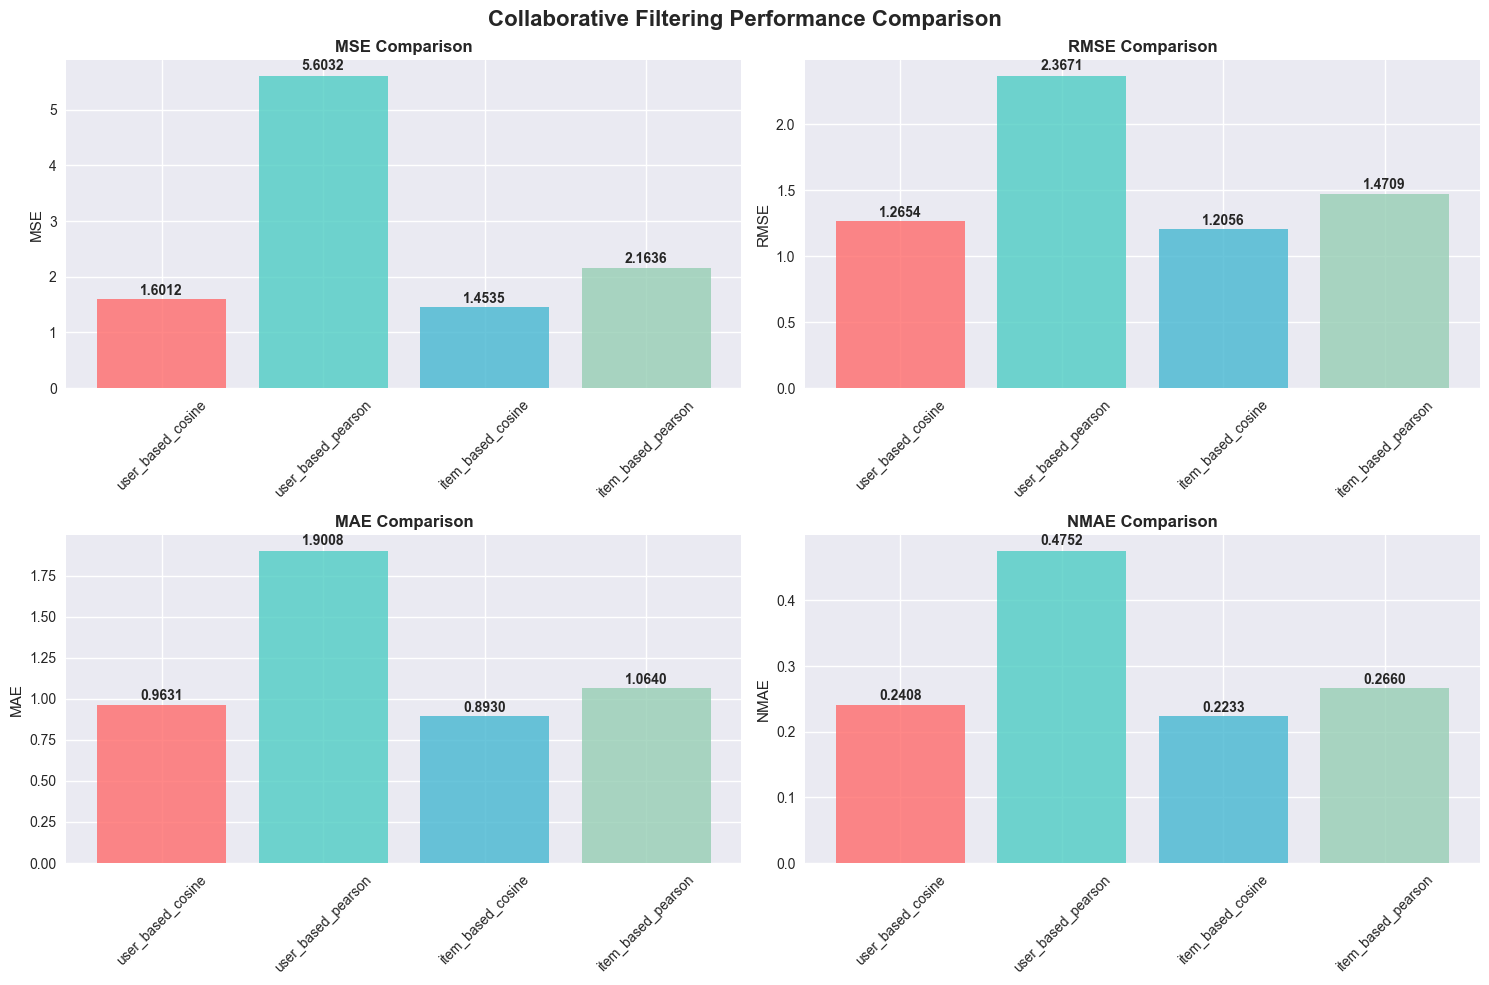

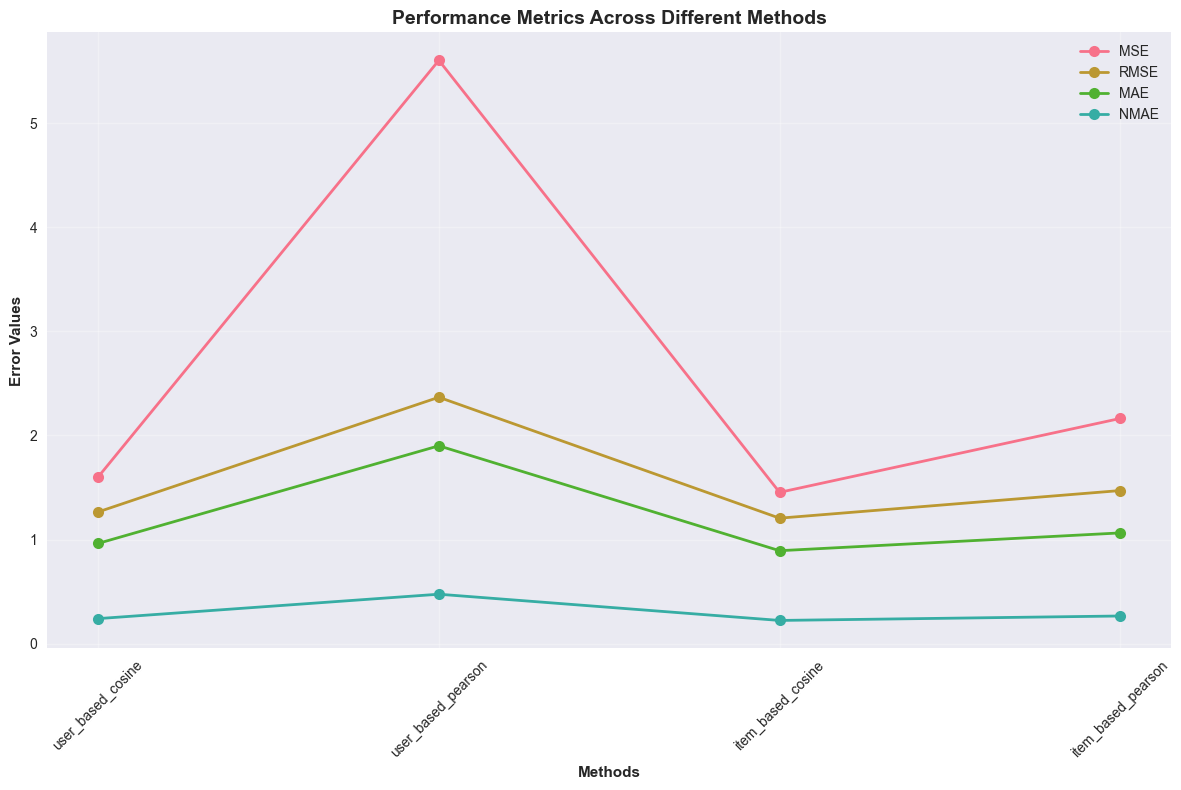


PERFORMANCE SUMMARY TABLE
      user_based_cosine  user_based_pearson  item_based_cosine  \
MSE              1.6012              5.6032             1.4535   
RMSE             1.2654              2.3671             1.2056   
MAE              0.9631              1.9008             0.8930   
NMAE             0.2408              0.4752             0.2233   

      item_based_pearson  
MSE               2.1636  
RMSE              1.4709  
MAE               1.0640  
NMAE              0.2660  

BEST PERFORMING METHODS
MSE: item_based_cosine (1.4535)
RMSE: item_based_cosine (1.2056)
MAE: item_based_cosine (0.8930)
NMAE: item_based_cosine (0.2233)

Evaluation Complete!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

class CollaborativeFiltering:
    def __init__(self):
        self.user_item_matrix = None
        self.user_similarity = None
        self.item_similarity = None
        self.user_mean_ratings = None
        self.item_mean_ratings = None
        
    def load_data(self, train_path, test_path):
        """Load training and testing data"""
        self.train_df = pd.read_csv(train_path)
        self.test_df = pd.read_csv(test_path)
        
        # Create user-item matrix
        self.user_item_matrix = self.train_df.pivot_table(
            index='username', 
            columns='id_product', 
            values='rating'
        ).fillna(0)
        
        # Calculate mean ratings
        self.user_mean_ratings = self.train_df.groupby('username')['rating'].mean()
        self.item_mean_ratings = self.train_df.groupby('id_product')['rating'].mean()
        
        print(f"Training data shape: {self.train_df.shape}")
        print(f"Testing data shape: {self.test_df.shape}")
        print(f"User-Item matrix shape: {self.user_item_matrix.shape}")
        
    def calculate_user_similarity(self, method='cosine'):
        """Calculate user-user similarity"""
        if method == 'cosine':
            # Replace 0 with NaN for better cosine similarity calculation
            matrix = self.user_item_matrix.replace(0, np.nan)
            matrix_filled = matrix.fillna(0)
            self.user_similarity = cosine_similarity(matrix_filled)
        elif method == 'pearson':
            n_users = len(self.user_item_matrix)
            self.user_similarity = np.zeros((n_users, n_users))
            
            for i in range(n_users):
                for j in range(n_users):
                    if i == j:
                        self.user_similarity[i, j] = 1.0
                    else:
                        user_i = self.user_item_matrix.iloc[i].values
                        user_j = self.user_item_matrix.iloc[j].values
                        
                        # Find common items (non-zero ratings)
                        mask = (user_i != 0) & (user_j != 0)
                        if np.sum(mask) > 1:
                            corr, _ = pearsonr(user_i[mask], user_j[mask])
                            self.user_similarity[i, j] = corr if not np.isnan(corr) else 0
                        else:
                            self.user_similarity[i, j] = 0
                            
    def calculate_item_similarity(self, method='cosine'):
        """Calculate item-item similarity"""
        if method == 'cosine':
            matrix = self.user_item_matrix.T.replace(0, np.nan)
            matrix_filled = matrix.fillna(0)
            self.item_similarity = cosine_similarity(matrix_filled)
        elif method == 'pearson':
            n_items = len(self.user_item_matrix.columns)
            self.item_similarity = np.zeros((n_items, n_items))
            
            for i in range(n_items):
                for j in range(n_items):
                    if i == j:
                        self.item_similarity[i, j] = 1.0
                    else:
                        item_i = self.user_item_matrix.iloc[:, i].values
                        item_j = self.user_item_matrix.iloc[:, j].values
                        
                        # Find common users (non-zero ratings)
                        mask = (item_i != 0) & (item_j != 0)
                        if np.sum(mask) > 1:
                            corr, _ = pearsonr(item_i[mask], item_j[mask])
                            self.item_similarity[i, j] = corr if not np.isnan(corr) else 0
                        else:
                            self.item_similarity[i, j] = 0
    
    def predict_user_based(self, user, item, k=50):
        """User-based collaborative filtering prediction"""
        if user not in self.user_item_matrix.index:
            return self.item_mean_ratings.get(item, 3.0)
        
        if item not in self.user_item_matrix.columns:
            return self.user_mean_ratings.get(user, 3.0)
            
        user_idx = self.user_item_matrix.index.get_loc(user)
        item_idx = self.user_item_matrix.columns.get_loc(item)
        
        # Get similarities for this user
        similarities = self.user_similarity[user_idx]
        
        # Find users who rated this item
        rated_users = self.user_item_matrix.iloc[:, item_idx] != 0
        rated_users_indices = np.where(rated_users)[0]
        
        if len(rated_users_indices) == 0:
            return self.user_mean_ratings.get(user, 3.0)
        
        # Get similarities and ratings for users who rated this item
        valid_similarities = similarities[rated_users_indices]
        valid_ratings = self.user_item_matrix.iloc[rated_users_indices, item_idx].values
        
        if len(valid_similarities) == 0:
            return self.user_mean_ratings.get(user, 3.0)
        
        # Sort by similarity and take top-k
        top_k_indices = np.argsort(valid_similarities)[-k:]
        top_similarities = valid_similarities[top_k_indices]
        top_ratings = valid_ratings[top_k_indices]
        
        # Calculate weighted average
        if np.sum(np.abs(top_similarities)) == 0:
            return self.user_mean_ratings.get(user, 3.0)
        
        prediction = np.sum(top_similarities * top_ratings) / np.sum(np.abs(top_similarities))
        return max(1, min(5, prediction))
    
    def predict_item_based(self, user, item, k=50):
        """Item-based collaborative filtering prediction"""
        if user not in self.user_item_matrix.index:
            return self.item_mean_ratings.get(item, 3.0)
        
        if item not in self.user_item_matrix.columns:
            return self.user_mean_ratings.get(user, 3.0)
            
        user_idx = self.user_item_matrix.index.get_loc(user)
        item_idx = self.user_item_matrix.columns.get_loc(item)
        
        # Get similarities for this item
        similarities = self.item_similarity[item_idx]
        
        # Find items rated by this user
        rated_items = self.user_item_matrix.iloc[user_idx] != 0
        rated_items_indices = np.where(rated_items)[0]
        
        if len(rated_items_indices) == 0:
            return self.item_mean_ratings.get(item, 3.0)
        
        # Get similarities and ratings for items rated by this user
        valid_similarities = similarities[rated_items_indices]
        valid_ratings = self.user_item_matrix.iloc[user_idx, rated_items_indices].values
        
        if len(valid_similarities) == 0:
            return self.item_mean_ratings.get(item, 3.0)
        
        # Sort by similarity and take top-k
        top_k_indices = np.argsort(valid_similarities)[-k:]
        top_similarities = valid_similarities[top_k_indices]
        top_ratings = valid_ratings[top_k_indices]
        
        # Calculate weighted average
        if np.sum(np.abs(top_similarities)) == 0:
            return self.item_mean_ratings.get(item, 3.0)
        
        prediction = np.sum(top_similarities * top_ratings) / np.sum(np.abs(top_similarities))
        return max(1, min(5, prediction))
    
    def evaluate(self, method='user_based', similarity='cosine', train_path=None, test_path=None):
        """Evaluate the recommendation system"""
        print(f"\nEvaluating {method} with {similarity} similarity...")
        
        # Load appropriate data for the method
        if train_path and test_path:
            self.load_data(train_path, test_path)
        
        # Calculate similarity matrix
        if method == 'user_based':
            self.calculate_user_similarity(similarity)
        else:
            self.calculate_item_similarity(similarity)
        
        predictions = []
        actuals = []
        
        # Make predictions for test set
        for _, row in self.test_df.iterrows():
            user = row['username']
            item = row['id_product']
            actual = row['rating']
            
            if method == 'user_based':
                pred = self.predict_user_based(user, item)
            else:
                pred = self.predict_item_based(user, item)
            
            predictions.append(pred)
            actuals.append(actual)
        
        predictions = np.array(predictions)
        actuals = np.array(actuals)
        
        # Calculate metrics
        mse = mean_squared_error(actuals, predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(actuals, predictions)
        
        # NMAE (Normalized MAE) - normalized by rating range
        rating_range = 5 - 1  # assuming 1-5 rating scale
        nmae = mae / rating_range
        
        return {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'NMAE': nmae,
            'predictions': predictions,
            'actuals': actuals
        }

def run_evaluation():
    """Run complete evaluation for all methods"""
    
    # Initialize the system
    cf = CollaborativeFiltering()
    
    # Define file paths for different methods
    data_paths = {
        'user_based': {
            'train': '../data/collabrative/user_based_training_set.csv',
            'test': '../data/collabrative/user_based_testing_set.csv'
        },
        'item_based': {
            'train': '../data/collabrative/item_based_training_set.csv',
            'test': '../data/collabrative/item_based_testing_set.csv'
        }
    }
    
    # Define methods to evaluate
    methods = [
        ('user_based', 'cosine'),
        ('user_based', 'pearson'),
        ('item_based', 'cosine'),
        ('item_based', 'pearson')
    ]
    
    results = {}
    
    # Evaluate each method
    for method, similarity in methods:
        method_name = f"{method}_{similarity}"
        
        # Get appropriate data paths
        train_path = data_paths[method]['train']
        test_path = data_paths[method]['test']
        
        print(f"\nLoading data for {method_name}:")
        print(f"Training: {train_path}")
        print(f"Testing: {test_path}")
        
        results[method_name] = cf.evaluate(method, similarity, train_path, test_path)
        
        print(f"\n{method_name.upper()} Results:")
        print(f"MSE: {results[method_name]['MSE']:.4f}")
        print(f"RMSE: {results[method_name]['RMSE']:.4f}")
        print(f"MAE: {results[method_name]['MAE']:.4f}")
        print(f"NMAE: {results[method_name]['NMAE']:.4f}")
    
    return results

def plot_results(results):
    """Create visualization of results"""
    
    # Prepare data for plotting
    methods = list(results.keys())
    metrics = ['MSE', 'RMSE', 'MAE', 'NMAE']
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Collaborative Filtering Performance Comparison', fontsize=16, fontweight='bold')
    
    # Plot each metric
    for i, metric in enumerate(metrics):
        ax = axes[i // 2, i % 2]
        
        values = [results[method][metric] for method in methods]
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
        
        bars = ax.bar(methods, values, color=colors, alpha=0.8)
        ax.set_title(f'{metric} Comparison', fontweight='bold')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Create line plot showing trends
    plt.figure(figsize=(12, 8))
    
    x_pos = range(len(methods))
    
    for metric in metrics:
        values = [results[method][metric] for method in methods]
        plt.plot(x_pos, values, marker='o', linewidth=2, markersize=8, label=metric)
    
    plt.xlabel('Methods', fontweight='bold')
    plt.ylabel('Error Values', fontweight='bold')
    plt.title('Performance Metrics Across Different Methods', fontsize=14, fontweight='bold')
    plt.xticks(x_pos, methods, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Create summary table
    print("\n" + "="*80)
    print("PERFORMANCE SUMMARY TABLE")
    print("="*80)
    
    df_results = pd.DataFrame({
        method: [results[method][metric] for metric in metrics]
        for method in methods
    }, index=metrics)
    
    print(df_results.round(4))
    
    # Find best performing method for each metric
    print("\n" + "="*80)
    print("BEST PERFORMING METHODS")
    print("="*80)
    
    for metric in metrics:
        best_method = min(methods, key=lambda x: results[x][metric])
        best_value = results[best_method][metric]
        print(f"{metric}: {best_method} ({best_value:.4f})")

if __name__ == "__main__":
    # Run the evaluation
    print("Starting Collaborative Filtering Evaluation...")
    print("="*60)
    
    results = run_evaluation()
    
    print("\n" + "="*60)
    print("Creating Visualizations...")
    
    plot_results(results)
    
    print("\nEvaluation Complete!")